<a href="https://colab.research.google.com/github/amalvarezme/AprendizajeMaquina/blob/main/2_Kernels_GaussianProcess/1_KernelRidgeRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#M�nimos cuadrados para regresi�n y su extensi�n no lineal

[sklearn.linear model.LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

Regresor lineal por m�nimos cuadrados

\begin{equation}
\omega^* = \arg\min_\omega \|y-Xw\|^2_2
\end{equation}


[sklearn.kernel ridge.KernelRidge](https://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html)

Regresor r�gido kernel



\begin{equation}
\omega^* = \arg\min_\omega \|y-\Phi \omega\|^2_2 + \alpha\|\omega\|^2_2
\end{equation}

\begin{equation}
\omega^* = (\Phi^\top \Phi+\alpha I)^{-1}\Phi^\top y
\end{equation}


\begin{equation}
\omega^* = \Phi^\top(\Phi \Phi^\top+\alpha I)^{-1}y = k(\cdot)^\top(K+\alpha I)^{-1}y
\end{equation}

# Ejercicio 1

- Presente la soluci�n al problema de optimizaci�n kernel ridge (Ver [Kernel Ridge Regression](https://web2.qatar.cmu.edu/~gdicaro/10315-Fall19/additional/welling-notes-on-kernel-ridge.pdf) y [material de apoyo](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/2_Kernels_GaussianProcess/1-introKernels.pdf) p�gs 8 y 9).

$$\Phi = B$$

$$R = I$$ $$P=?$$ factorizar para que quede $\alpha$

##**Ejemplo**

- Se pretende generar un modelo de regresi�n bajo entradas con ruido blanco Gaussiano, con $\mu_\eta=0$, para seguir una funci�n no lineal tipo sinc(x).

- $y = {\rm{sinc}}(x)+\eta$;  
con $\eta\sim p(\eta)=\mathscr{N}(\eta|\mu_\eta,\sigma_\eta^2)=\frac{1}{\sqrt{2\pi\sigma^2_\eta}}\exp\left(\frac{-\|\eta-\mu_\eta\|_2^2}{2\sigma^2_\eta}\right)$

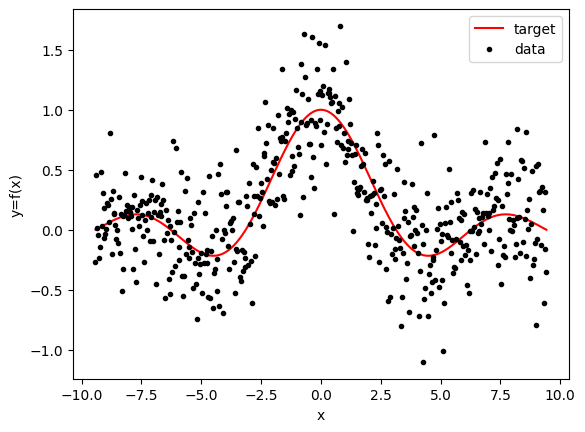

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
N = 500 #n�mero de muestras
X = np.linspace(-3*np.pi,3*np.pi,N) #vector de entrada
y = np.sinc(X/np.pi) #funci�n sinc -> objetivo
var = 0.1 #varianza del ruido
mue = 0 #media del ruido
noise = mue + np.sqrt(var)*np.random.randn(X.shape[0])#ruido blanco
yn = y + noise #se�al co ruido
plt.plot(X,y,'r',label='target' )
plt.plot(X,yn,'k.',label='data')
plt.legend()
plt.xlabel('x')
plt.ylabel('y=f(x)')
plt.show()

**Nota:** $${\rm{sinc}}(\theta)=\frac{\sin(\theta)}{\theta}$$

- Se crean los vectores de entrada y salida tipo aprendizaje de m�quina.

In [2]:
ydata = yn.reshape(-1,1)
Xdata = X.reshape(-1,1)
print(Xdata.shape) # N = 500 muestras, P = 1 atributos
print(ydata.shape) # N = 500, regresion univarida

(500, 1)
(500, 1)


- Se entrenar� un modelo de aprendizaje con scikitlearn

(350, 1)
(150, 1)


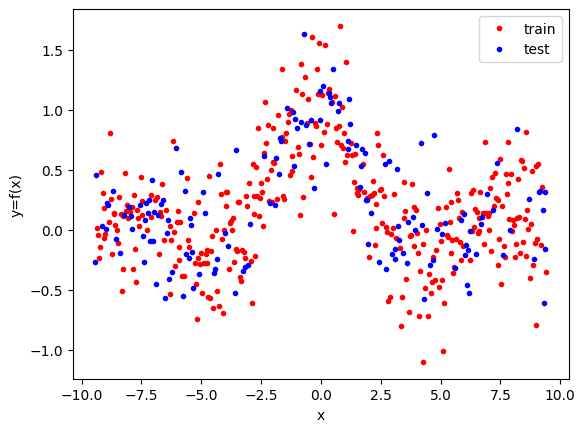

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score, cross_val_predict

X_train, X_test, y_train, y_test = train_test_split(Xdata, ydata,
                                                    test_size=0.3)#particionar train y test

print(X_train.shape)
print(X_test.shape)

plt.plot(X_train,y_train,'r.',label='train' )
plt.plot(X_test,y_test,'b.',label='test')
plt.legend()
plt.xlabel('x')
plt.ylabel('y=f(x)')
plt.show()

#  Bias-Variance Tradeoff

La validaci�n cruzada, o estrategias similares, nos permiten entender, al menos un poco, la capacidad de generalizaci�n de nuestro modelo:

## TotalError=Bias$^2$ +Variance+IrreducibleError

![bias_variance](https://media.geeksforgeeks.org/wp-content/uploads/20200107023418/1_oO0KYF7Z84nePqfsJ9E0WQ.png)

# Kernel Rbf

- Se utilizar� el modelo [KernelRidge](https://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html) con funci�n kernel tipo radial basis function (rbf):


$$\kappa(x,x') = \exp\left(\frac{-\gamma\|x-x'\|^2_2}{2}\right)$$

**Nota:** el hiperpar�metro $\gamma\in\mathbb{R}^+$ se conoce como precisi�n y pretende escalar la noci�n de parecido entre los puntos. La precisi�n se relaciona comunmente con el par�metro ancho de banda ("varianza") $\sigma\in\mathbb{R}^+$ del modelo rbf, seg�n:

$$\gamma=\frac{1}{\sigma^2}$$

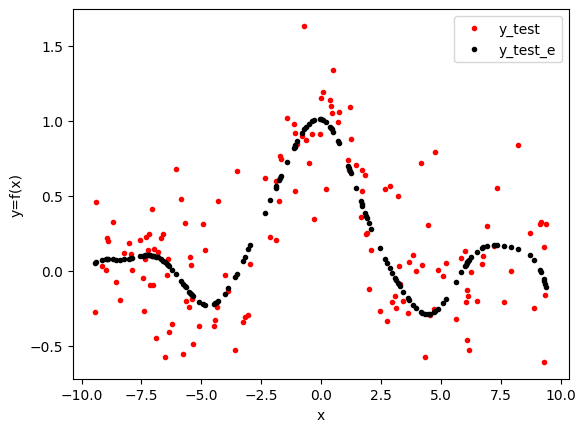

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import Pipeline
gamma = 0.1 #gamma
alpha = 0.001 # valor de regularizaci�n
reg = KernelRidge(kernel='rbf',gamma=gamma, alpha = alpha)
reg.fit(X_train,y_train) #ajustar solo sobre train
#prediccion
y_test_e = reg.predict(X_test)
y_train_e = reg.predict(X_train)

plt.plot(X_test,y_test,'r.',label='y_test' )
plt.plot(X_test,y_test_e,'k.',label='y_test_e')
plt.legend()
plt.xlabel('x')
plt.ylabel('y=f(x)')
plt.show()

- Es  necesario encontar unos buenos hiperpar�metros para seguir la funci�n no lineal

In [5]:
steps=[('reg', KernelRidge(kernel = 'rbf'))]
parameters = {'reg__alpha' : [0,1e-3,1e-2,0.1,1,10,100,1000],
              'reg__gamma': [1e-4,1e-3,1e-2,0.1,1,10,100,1000],
              }

pipeline = Pipeline(steps = steps)

grid_search = GridSearchCV(pipeline, parameters, n_jobs=4,cv=10,
                           scoring='neg_mean_absolute_error',verbose=10,refit=True)

grid_search.fit(X_train, y_train)
#mejor modelo entrenado
best_model = grid_search.best_estimator_

print("\nMejores par�metros:\n")
print(grid_search.best_params_)

Fitting 10 folds for each of 64 candidates, totalling 640 fits

Mejores par�metros:

{'reg__alpha': 1, 'reg__gamma': 0.1}


- Se evaluan los datos de test y train con el mejor modelo encontrado

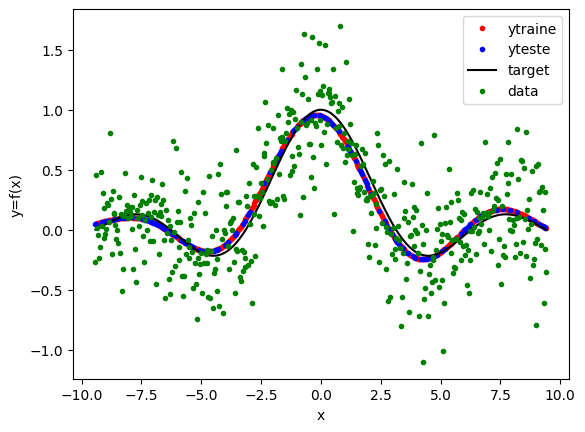

In [6]:
y_test_e = grid_search.best_estimator_.predict(X_test)
y_train_e = grid_search.best_estimator_.predict(X_train)
plt.plot(X_train,y_train_e,'r.',label='ytraine' )
plt.plot(X_test,y_test_e,'b.',label='yteste')
plt.plot(X,y,'k',label='target' )
plt.plot(Xdata,ydata,'g.',label='data' )
plt.legend()
plt.xlabel('x')
plt.ylabel('y=f(x)')
plt.show()

- Visualicemos la funci�n kernel:

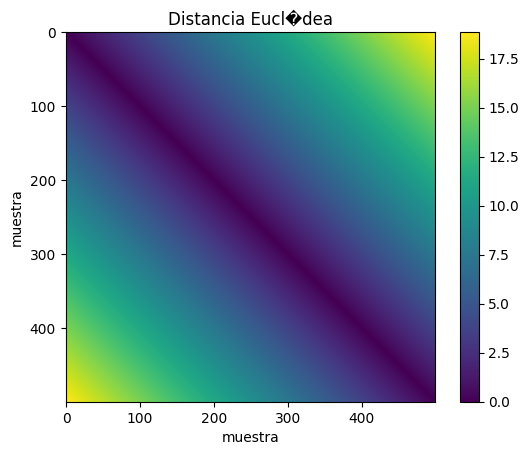

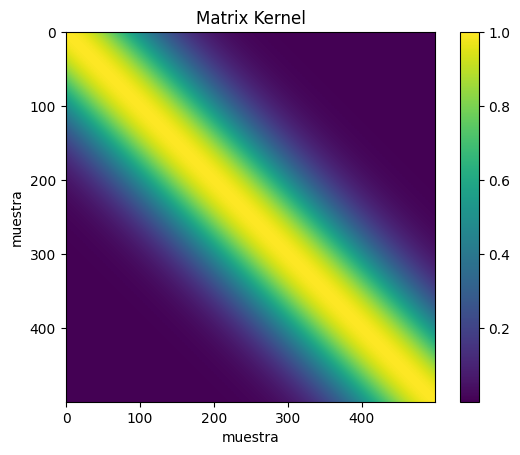

In [7]:
from sklearn.metrics import pairwise_distances as dist

D = dist(X.reshape(-1,1),X.reshape(-1,1)) #disimilitud
K = np.exp(-.5*gamma*D**2)
D.shape
plt.imshow(D)
plt.colorbar()
plt.xlabel('muestra')
plt.ylabel('muestra')
plt.title('Distancia Eucl�dea')
plt.show()

plt.imshow(K)
plt.colorbar()
plt.xlabel('muestra')
plt.ylabel('muestra')
plt.title('Matrix Kernel')
plt.show()

Recuerde que:

\begin{equation}
\kappa(x,x') = \frac{1}{\sqrt{2\pi \sigma^2}}\exp\left(\frac{-\|x-x'\|_2^2}{2\sigma^2}\right) = \frac{1}{\sqrt{2\pi \sigma^2}}\exp\left(\frac{-\gamma\|x-x'\|_2^2}{2}\right)
\end{equation}

#Ejercicio 2

- Visualice el kernel rbf para diferentes condiciones de ruido sintonizando los hiperpar�metros del modelo utilizando gridsearch. *Ayuda*: modifique la varianza del ruido.

- Realice una descomposici�n en valores propios de la matriz kernel para cada una de las condiciones de ruido del punto anterior, qu� puede discutir sobre el espectro de la matr�z y su influencia en el modelo predictivo de kernel ridge?. Cu�l es la relaci�n entre el espectro visualizado y el hiperpar�metro de regularizaci�n o penalidad encontrado por gridsearch en cada caso?. *Ayuda*: utilizando numpy encuentre la descomposici�n de valores y vectores propios de $\mathbf{K}$ y $\mathbf{K}+\alpha\mathbf{I}$, seg�n los valores de $\gamma$ y $\alpha$ encontrados por GridsearchCV ante cada condici�n de ruido evaluada.




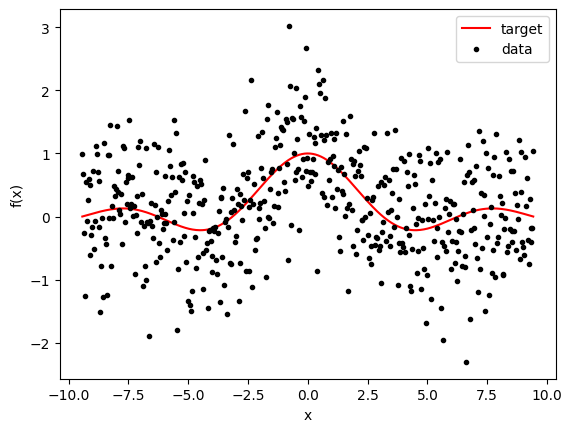

In [8]:
#Ayuda de c�digo:
N = 500 #n�mero de muestras
X = np.linspace(-3*np.pi,3*np.pi,N) #vector de entrada
y = np.sinc(X/np.pi) #funci�n sinc -> objetivo
var = 0.5 #varianza del ruido-> PROBAR DISTINTOS VALORES
mue = 0 #media del ruido
noise = mue + np.sqrt(var)*np.random.randn(X.shape[0])#ruido blanco
yn = y + noise #se�al co ruido
plt.plot(X,y,'r',label='target' )
plt.plot(X,yn,'k.',label='data')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

In [9]:
Xdata = X.reshape(-1,1) #N=500, P= 1
y = y.reshape(-1,1)
ydata = yn.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(Xdata, ydata,
                                                    test_size=0.3)#particionar train y test

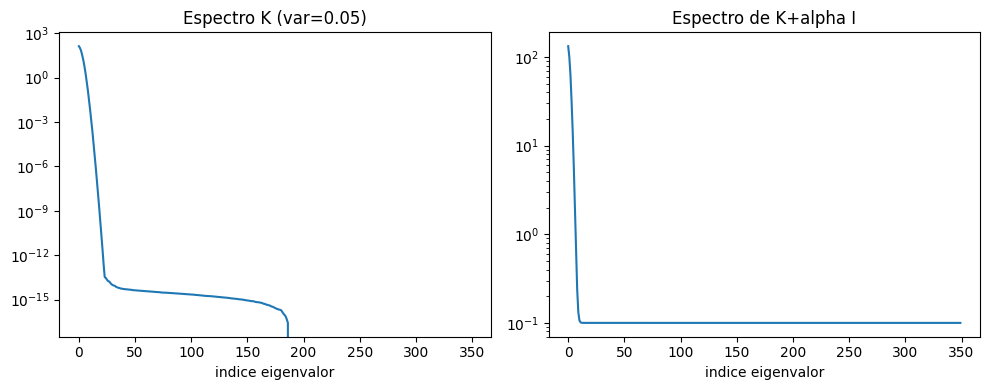

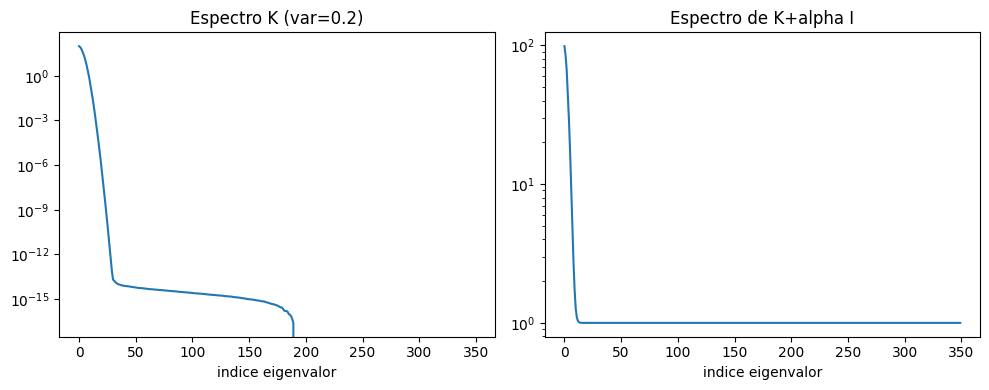

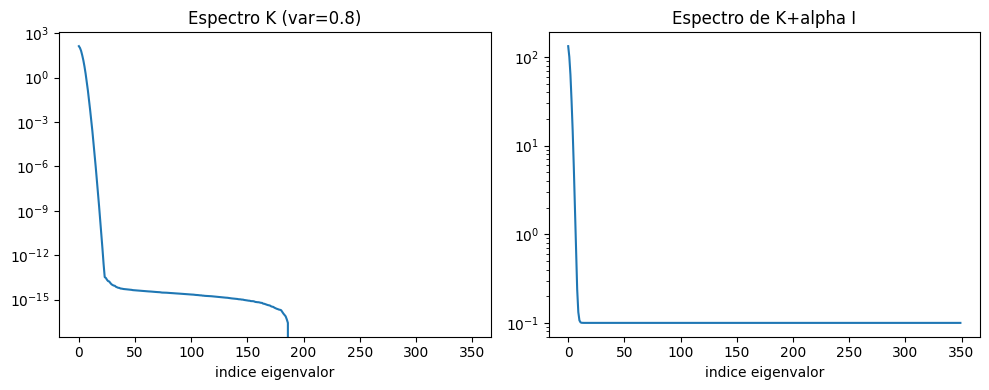

,var_ruido,alpha,gamma,mse_test
0,0.05,0.1,0.05,0.049286
1,0.20,1.0,0.10,0.172558
2,0.80,0.1,0.05,0.789381


In [10]:
# Gridsearch con kernel rbf para diferentes varianzas de ruido y espectro de la matriz kernel
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import rbf_kernel
import pandas as pd

rng = np.random.default_rng(42)
noise_variances = [0.05, 0.2, 0.8]
param_grid = {
    "alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1.0],
    "gamma": [1e-2, 5e-2, 1e-1, 0.5, 1.0, 2.0],
}

resumen = []
for var_ruido in noise_variances:
    ruido = rng.normal(0, np.sqrt(var_ruido), size=y.shape[0])
    datos_y = (y.ravel() + ruido).reshape(-1, 1)

    X_train, X_test, y_train, y_test = train_test_split(
        X.reshape(-1, 1),
        datos_y,
        test_size=0.3,
        random_state=123,
    )

    modelo = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid=param_grid,
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    params = modelo.best_params_
    resumen.append(
        {
            "var_ruido": var_ruido,
            "alpha": params["alpha"],
            "gamma": params["gamma"],
            "mse_test": mse,
        }
    )

    # Espectro de la matriz kernel y la versión regularizada
    K = rbf_kernel(X_train, X_train, gamma=params["gamma"])
    eig_vals = np.linalg.eigvalsh(K)
    eig_vals_reg = np.linalg.eigvalsh(K + params["alpha"] * np.eye(K.shape[0]))

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.semilogy(np.sort(eig_vals)[::-1])
    plt.title(f"Espectro K (var={var_ruido})")
    plt.xlabel("indice eigenvalor")
    plt.subplot(1, 2, 2)
    plt.semilogy(np.sort(eig_vals_reg)[::-1])
    plt.title("Espectro de K+alpha I")
    plt.xlabel("indice eigenvalor")
    plt.tight_layout()
    plt.show()

pd.DataFrame(resumen)
